In [11]:
import numpy as np
import cv2
import os
from PIL import Image, ImageDraw
from skimage.feature import graycomatrix, graycoprops, hog
from skimage.color import rgb2gray
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.utils import shuffle
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import xgboost as xgb

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# _________________________________________Load Feature Extraction Vectores ________________________________
# ____________________________________ hog or glcm or orb , vgg , yolo , resnet ____________________________


In [ ]:
# load Feature Extraction Vectors ( hog or glcm or orb , vgg , yolo , resnet )
import numpy as np

# Set feature_type to one of: 'all', 'hog', 'glcm', 'orb',vgg','yolo','resnet'
feature_type = 'vgg'  # Change to 'all', 'hog', 'glcm', or 'orb' as needed

# Load all arrays for shape info and switching
hog_features_array = np.load('Bin_Features/hog_features_array.npy')
glcm_features_array = np.load('Bin_Features/glcm_features_array.npy')
orb_features_array = np.load('Bin_Features/orb_features_array.npy')
vgg_features_array = np.load('Bin_Features/vgg_features_array.npy')
yolo_features_array = np.load('Bin_Features/yolo_features_array.npy')
resnet_features_array = np.load('Bin_Features/resnet_features_array.npy')

features_array = None
labels_array = np.load('Bin_Features/labels_array_all_algorithms.npy')

if feature_type == 'all':
    features_array = np.load('Bin_Features/features_array_all_algorithms.npy')
    print("Loaded combined features.")
elif feature_type == 'hog':
    features_array = hog_features_array
    print("Loaded HOG features.")
elif feature_type == 'glcm':
    features_array = glcm_features_array
    print("Loaded GLCM features.")
elif feature_type == 'orb':
    features_array = orb_features_array
    print("Loaded ORB features.")
elif feature_type == 'vgg':
    features_array = vgg_features_array
    print("Loaded vgg features.")
elif feature_type == 'resnet':
    features_array = resnet_features_array
    print("Loaded resnet features.")
elif feature_type == 'yolo':
    features_array = yolo_features_array
    print("Loaded yolo features.")


else:
    raise ValueError("Invalid feature_type. Choose from 'all', 'hog', 'glcm', 'orb'.")

print(' features shape:', features_array.shape)
print('Labels shape:', labels_array.shape)

print(f" ------++++++++ load Feature Extraction Vectors is Done :- {feature_type} +++++++++-------------")


Loaded vgg features.
 features shape: (744, 512)
Labels shape: (744,)
 ------++++++++ load Feature Extraction Vectors is Done :- vgg +++++++++-------------


In [24]:
# feature selection Harmony 
#from hormany_selection import harmony_search_feature_selection

'''''
# 3. Shuffle the data
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split    
from imblearn.over_sampling import RandomOverSampler

X_combin, y_combin = shuffle(features_array, labels_array, random_state=2)
np.save('hormany_FS/Label_hormany.npy', y_combin)

# تم تقسيم البيانات ليتم ادخال فقط بيانات التدريب الى خوارزمية اختيار الصفات
# This is to ensure that the feature selection algorithm only sees training data
# Split into training and testing sets
X_train_comb, X_test_comb, y_comb_train, y_comb_test = train_test_split(X_combin, y_combin, test_size=0.25, random_state=42)


# Handle imbalance using oversampling
oversample = RandomOverSampler(sampling_strategy='minority')
X_train_combin, y_train_combin = oversample.fit_resample(X_train_comb, y_comb_train)

# Feature selection using Harmony Search
print('feature shape befor FS :', X_combin.shape)

'''

feature shape befor FS : (744, 128)


In [12]:
from data_processing import (
    remove_rows_per_class,
    oversample_to_original_counts,
    custom_oversample_to_target,
    process_data_for_accuracy
)

print("METHOD Random Oversampling to Original Counts")
X_processed1, y_processed1 = process_data_for_accuracy(
        features_array, labels_array,
        removal_ratio=0.6,
        oversampling_method='random',
        random_state=42
    )
    

print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)
    
    # Choose which processed dataset to use (X_processed1, X_processed2, or X_processed3)
X_combin, y_combin = X_processed1, y_processed1  # Using method 1 as example
y_combin
np.save('hormany_FS/Label_hormany.npy', y_combin)

# تم تقسيم البيانات ليتم ادخال فقط بيانات التدريب الى خوارزمية اختيار الصفات
# This is to ensure that the feature selection algorithm only sees training data
# Split into training and testing sets
X_train_comb, X_test_comb, y_comb_train, y_comb_test = train_test_split(X_combin, y_combin, test_size=0.25, random_state=42, stratify=y_combin)


# Handle imbalance using oversampling
oversample = RandomOverSampler(sampling_strategy='minority')
X_train_combin, y_train_combin = oversample.fit_resample(X_train_comb, y_comb_train)

METHOD Random Oversampling to Original Counts

TRAIN-TEST SPLIT


In [13]:
# Feature selection ---- selected_features_glcm
# Initialize the classifier
# Define the number of features to select
#from hormany_selection import harmony_search_feature_selection
from harmony_feature_selection import harmony_search_feature_selection 

selected_features_comb, final_fitness = harmony_search_feature_selection(
    X_train_combin,
    y_train_combin,
    num_agents=20,
    max_iter=100,
    HMCR=0.9,
    PAR=0.3,
    min_features=10,
    early_stopping=10
)


print("Selected features_glcm (binary vector):", selected_features_comb)




Iteration 10/100
Best Fitness: 0.9352
Selected Features: 238/512

Stopping early - No improvement for 10 iterations

Feature selection completed.
Best Fitness: 0.9352
Number of selected features: 238
Selected feature indices: [  1   3   6   7   9  13  16  17  18  19  24  27  34  35  38  42  44  46
  47  49  51  54  57  60  61  64  65  67  73  74  75  76  81  84  85  86
  87  90  94  96 100 102 103 104 109 110 111 113 115 118 119 120 121 123
 124 125 128 130 135 136 137 139 140 141 145 146 147 150 155 160 161 168
 170 171 173 174 175 176 177 178 180 181 182 184 186 189 190 192 198 201
 203 204 205 209 211 213 217 218 221 222 223 225 227 229 230 231 232 233
 235 236 237 239 241 242 244 247 249 250 255 256 258 259 260 261 264 268
 269 270 272 273 275 276 280 281 282 285 286 291 293 294 295 300 303 305
 306 307 308 309 310 311 312 317 319 323 325 326 330 332 333 336 337 338
 340 342 343 345 348 351 355 357 358 362 368 369 374 376 377 379 380 381
 382 385 391 396 397 398 399 401 407 408 409

In [14]:
# Apply selected features on the entire dataset
# يتم تطيبق الصفات المختارة على جميع البيانات ( بيانات التدريب والاختبار ) البيانات التي الحصول عليها من استخلاص الصفات
from harmony_feature_selection import apply_selected_features

X_selected_comb = apply_selected_features(X_combin, selected_features_comb)

print('feature shape befor FS :', features_array.shape)
print('feature shape After FS :', X_selected_comb.shape)

if feature_type == 'all':
    np.save('hormany_FS/all_hormany.npy', X_selected_comb)
    print("Save hog_hormany.")
elif feature_type == 'hog':
    np.save('hormany_FS/hog_hormany.npy', X_selected_comb)
    print("Save hog_hormany.")
elif feature_type == 'glcm':
    np.save('hormany_FS/glcm_hormany.npy', X_selected_comb)
    print("Save glcm_hormany.")
elif feature_type == 'orb':
    np.save('hormany_FS/orb_hormany.npy', X_selected_comb)
    print("Save orb_hormany.")

elif feature_type == 'vgg':
    np.save('hormany_FS/vgg_hormany.npy', X_selected_comb)
    print("Save vgg_hormany.")
    
elif feature_type == 'resnet':
    np.save('hormany_FS/resnet_hormany.npy', X_selected_comb)
    print("Save resnet_hormany.")
elif feature_type == 'yolo':
    np.save('hormany_FS/yolo_hormany.npy', X_selected_comb)
    print("Save yolo_hormany.")


else:
    raise ValueError("Invalid feature_type. Choose from 'all', 'hog', 'glcm', 'orb', 'vgg', 'resnet', 'yolo'.")




feature shape befor FS : (744, 512)
feature shape After FS : (744, 238)
Save vgg_hormany.


# __________________________________ Test Stage _____________________________________________
# _________________________Load Feature Extraction Vectores After Feature selection________________________________
# ____________________________________ hog or glcm or orb , vgg , yolo , resnet ____________________________


In [15]:
# Load features and labels (change filename to use other algorithms)
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

#feature_type='yolo'  # Change to 'all', 'hog', 'glcm', 'orb', 'vgg', 'resnet', 'yolo' as needed
if feature_type == 'all':
    feature_hormany=np.load ('hormany_FS/all_hormany.npy')
    print("load hog_hormany.")
elif feature_type == 'hog':
    feature_hormany=np.load('hormany_FS/hog_hormany.npy')
    print("load hog_hormany.")
elif feature_type == 'glcm':
    feature_hormany=np.load('hormany_FS/glcm_hormany.npy')
    print("load glcm_hormany.")
elif feature_type == 'orb':
    feature_hormany=np.load('hormany_FS/orb_hormany.npy')
    print("load orb_hormany.")
elif feature_type == 'vgg':
    feature_hormany=np.load('hormany_FS/vgg_hormany.npy')
    print("load vgg_hormany.")
elif feature_type == 'resnet':
    feature_hormany=np.load('hormany_FS/resnet_hormany.npy')
    print("load resnet_hormany.")
elif feature_type == 'yolo':
    feature_hormany=np.load('hormany_FS/yolo_hormany.npy')
    print("load yolo_hormany.")

else:
    raise ValueError("Invalid feature_type. Choose from 'all', 'hog', 'glcm', 'orb', 'vgg', 'resnet', 'yolo'.")

labels=np.load('hormany_FS/Label_hormany.npy')

# Example: use all algorithms' features
features = feature_hormany
#labels = y_combin

# Encode string labels to integers if needed
if labels.dtype.type is np.str_ or labels.dtype.type is np.object_:
    le = LabelEncoder()
    labels = le.fit_transform(labels)

# Optionally scale features
#scaler = StandardScaler()
#features_scaled = scaler.fit_transform(features)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)


load vgg_hormany.


%%%%%%%%%%%%%%%%%%%%%%%%%%  Test wit Cross Validation %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


Evaluating RandomForest...

Evaluating ExtraTrees...

Evaluating AdaBoost...

Evaluating GradientBoosting...

Evaluating Bagging...

Evaluating LogisticRegression...

Evaluating SVM...

Evaluating KNN...

Evaluating GaussianNB...

Evaluating DecisionTree...

Evaluating XGBoost...

Classifier Comparison (Cross-Validation):
            Classifier  Accuracy  Precision    Recall        F1
1           ExtraTrees  0.965037   0.966200  0.964973  0.965007
0         RandomForest  0.963704   0.964876  0.963622  0.963677
10             XGBoost  0.962353   0.962924  0.962306  0.962336
4              Bagging  0.952929   0.954264  0.952775  0.952887
3     GradientBoosting  0.951605   0.952690  0.951532  0.951572
5   LogisticRegression  0.944885   0.946200  0.944811  0.944829
2             AdaBoost  0.942200   0.943985  0.942126  0.942130
9         DecisionTree  0.936804   0.937801  0.936775  0.936768
7                  KNN  0.823925   0.825512  0.823892  0.823698
6                  SVM  0.790323   

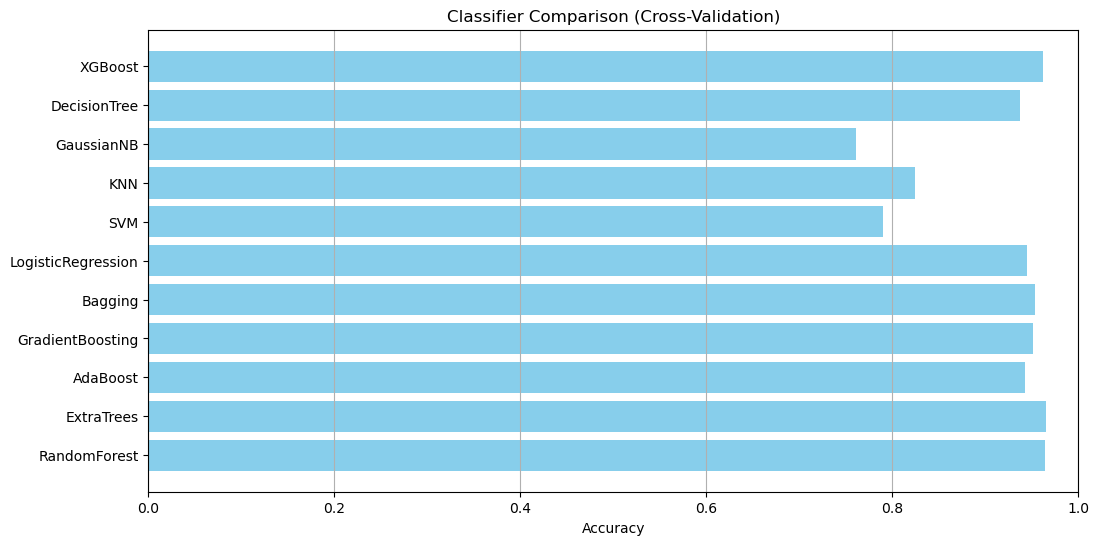

In [16]:
# Compare multiple classifiers using cross-validation
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, BaggingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

classifiers = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Bagging': BaggingClassifier(n_estimators=10, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'GaussianNB': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

summary = []
for name, clf in classifiers.items():
    print(f"\nEvaluating {name}...")
    scores = cross_validate(clf, features, labels, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    summary.append({
        'Classifier': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision_macro'].mean(),
        'Recall': scores['test_recall_macro'].mean(),
        'F1': scores['test_f1_macro'].mean()
    })

results_df = pd.DataFrame(summary)
print("\nClassifier Comparison (Cross-Validation):")
print(results_df.sort_values(by='Accuracy', ascending=False))

# Plotting the results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.barh(results_df['Classifier'], results_df['Accuracy'], color='skyblue')
plt.xlabel('Accuracy')
plt.title('Classifier Comparison (Cross-Validation)')
plt.xlim(0, 1)
plt.grid(axis='x')
plt.show()

%%%%%%%%%%%%%%%%%%%%%%%%% Test without Cross Validation %%%%%%%%%%%%%%%%%%%%%%%%%%%%%


Evaluating RandomForest
Training Accuracy: 0.9966
Test Accuracy: 0.9329


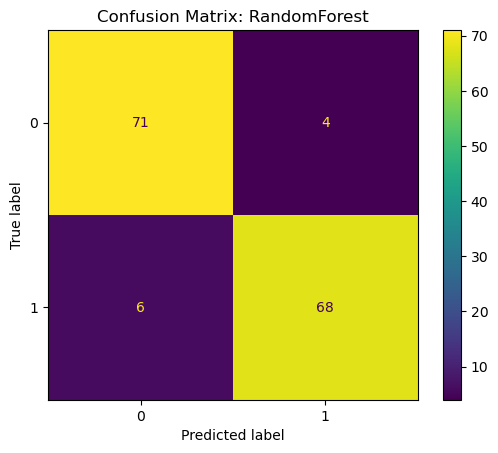

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93        75
           1       0.94      0.92      0.93        74

    accuracy                           0.93       149
   macro avg       0.93      0.93      0.93       149
weighted avg       0.93      0.93      0.93       149


Evaluating ExtraTrees
Training Accuracy: 0.9966
Test Accuracy: 0.9396


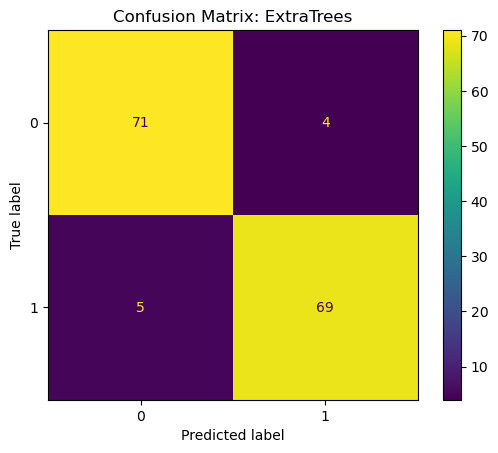

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        75
           1       0.95      0.93      0.94        74

    accuracy                           0.94       149
   macro avg       0.94      0.94      0.94       149
weighted avg       0.94      0.94      0.94       149


Evaluating AdaBoost
Training Accuracy: 0.9059
Test Accuracy: 0.8658


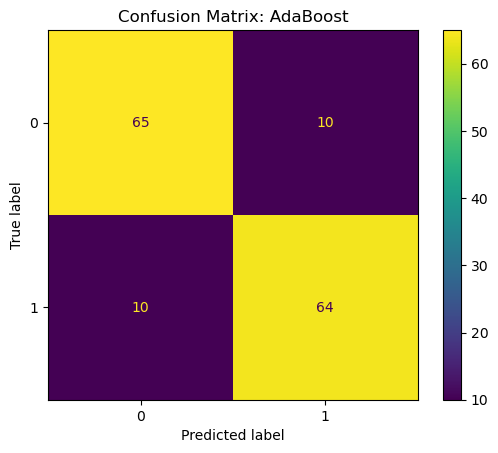

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        75
           1       0.86      0.86      0.86        74

    accuracy                           0.87       149
   macro avg       0.87      0.87      0.87       149
weighted avg       0.87      0.87      0.87       149


Evaluating GradientBoosting
Training Accuracy: 0.9866
Test Accuracy: 0.9463


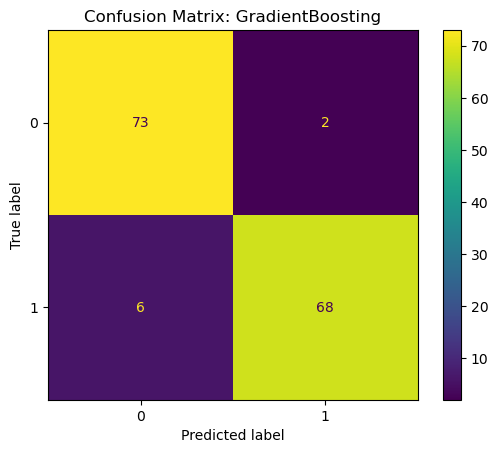

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95        75
           1       0.97      0.92      0.94        74

    accuracy                           0.95       149
   macro avg       0.95      0.95      0.95       149
weighted avg       0.95      0.95      0.95       149


Evaluating XGBoost
Training Accuracy: 0.9966
Test Accuracy: 0.9396


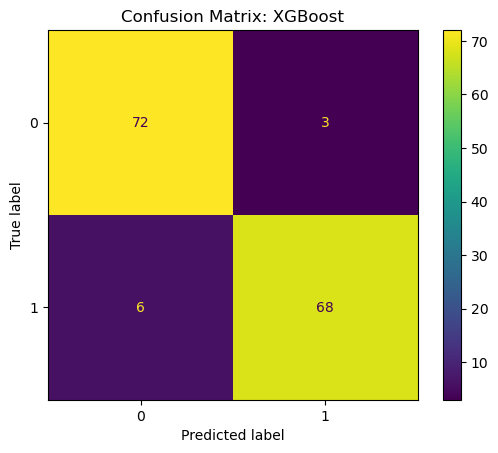

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        75
           1       0.96      0.92      0.94        74

    accuracy                           0.94       149
   macro avg       0.94      0.94      0.94       149
weighted avg       0.94      0.94      0.94       149


Evaluating LightGBM
Training Accuracy: 0.9966
Test Accuracy: 0.9463


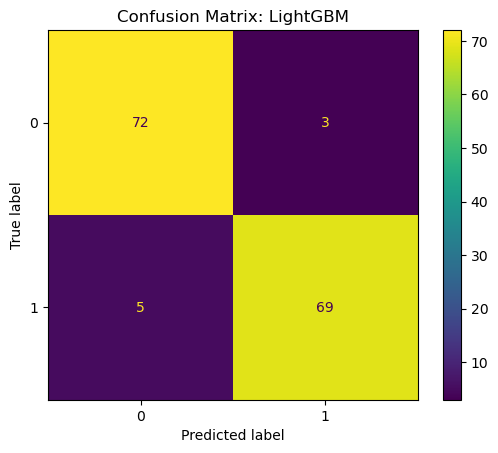

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        75
           1       0.96      0.93      0.95        74

    accuracy                           0.95       149
   macro avg       0.95      0.95      0.95       149
weighted avg       0.95      0.95      0.95       149


Evaluating Bagging
Training Accuracy: 0.9950
Test Accuracy: 0.9262


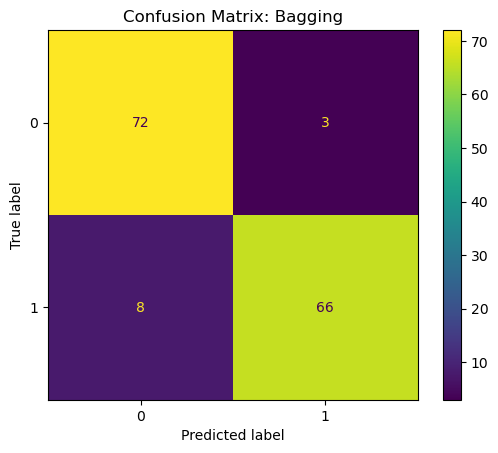

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        75
           1       0.96      0.89      0.92        74

    accuracy                           0.93       149
   macro avg       0.93      0.93      0.93       149
weighted avg       0.93      0.93      0.93       149


Evaluating LogisticRegression
Training Accuracy: 0.7042
Test Accuracy: 0.6980


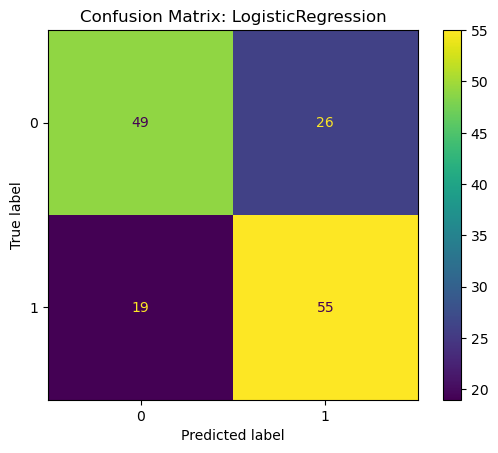

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.65      0.69        75
           1       0.68      0.74      0.71        74

    accuracy                           0.70       149
   macro avg       0.70      0.70      0.70       149
weighted avg       0.70      0.70      0.70       149


Evaluating RidgeClassifier
Training Accuracy: 0.7210
Test Accuracy: 0.7114


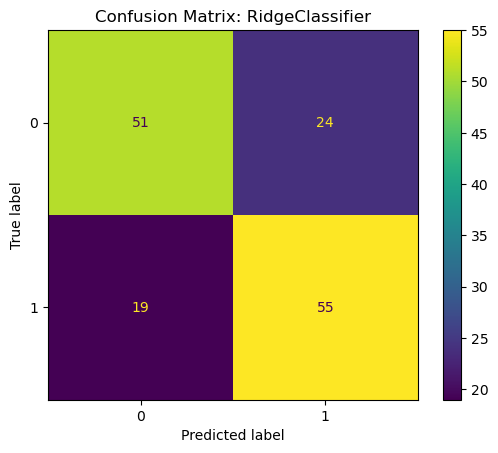

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.68      0.70        75
           1       0.70      0.74      0.72        74

    accuracy                           0.71       149
   macro avg       0.71      0.71      0.71       149
weighted avg       0.71      0.71      0.71       149


Evaluating SGDClassifier
Training Accuracy: 0.5950
Test Accuracy: 0.6040


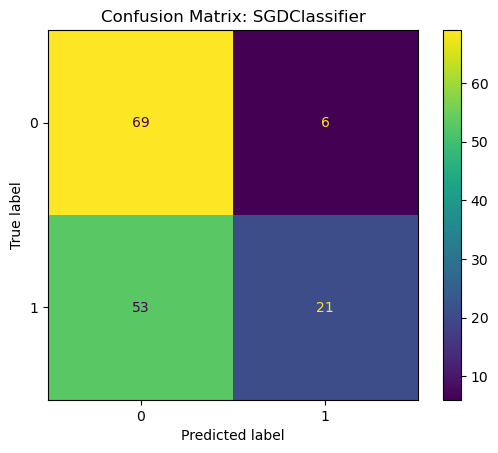

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.92      0.70        75
           1       0.78      0.28      0.42        74

    accuracy                           0.60       149
   macro avg       0.67      0.60      0.56       149
weighted avg       0.67      0.60      0.56       149


Evaluating PassiveAggressive
Training Accuracy: 0.6034
Test Accuracy: 0.6040


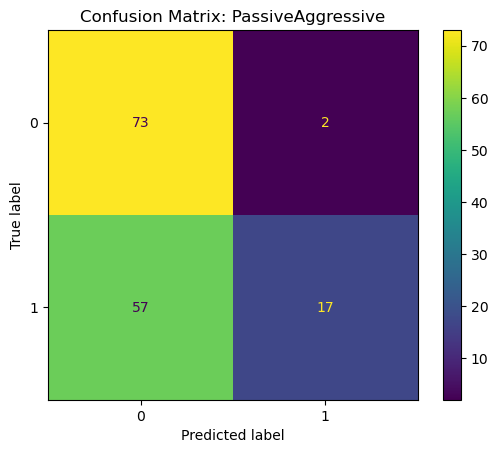

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.97      0.71        75
           1       0.89      0.23      0.37        74

    accuracy                           0.60       149
   macro avg       0.73      0.60      0.54       149
weighted avg       0.73      0.60      0.54       149


Evaluating Perceptron
Training Accuracy: 0.5328
Test Accuracy: 0.5034


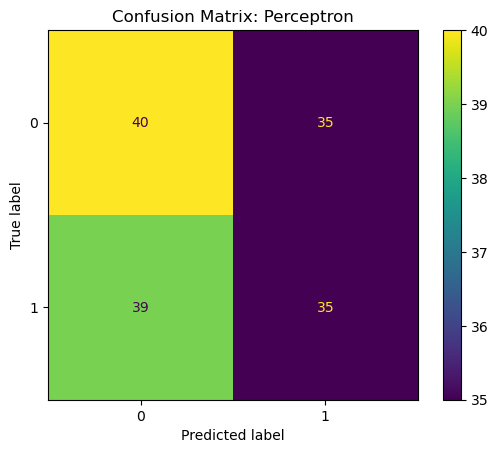

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.53      0.52        75
           1       0.50      0.47      0.49        74

    accuracy                           0.50       149
   macro avg       0.50      0.50      0.50       149
weighted avg       0.50      0.50      0.50       149


Evaluating SVM
Training Accuracy: 0.5950
Test Accuracy: 0.5839


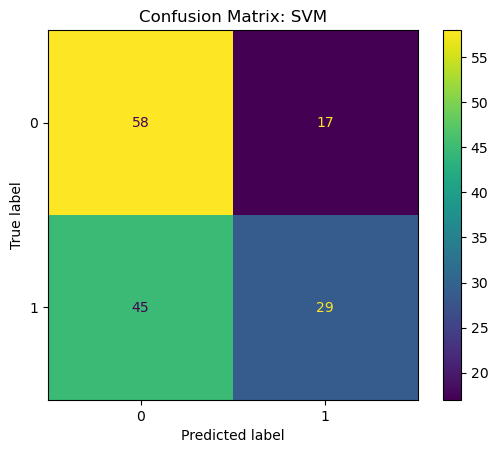

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.77      0.65        75
           1       0.63      0.39      0.48        74

    accuracy                           0.58       149
   macro avg       0.60      0.58      0.57       149
weighted avg       0.60      0.58      0.57       149


Evaluating LinearSVM
Training Accuracy: 0.7109
Test Accuracy: 0.6980


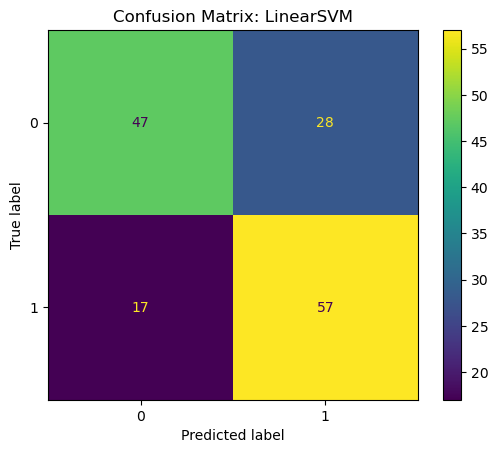

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.63      0.68        75
           1       0.67      0.77      0.72        74

    accuracy                           0.70       149
   macro avg       0.70      0.70      0.70       149
weighted avg       0.70      0.70      0.70       149


Evaluating NuSVM
Training Accuracy: 0.6353
Test Accuracy: 0.5772


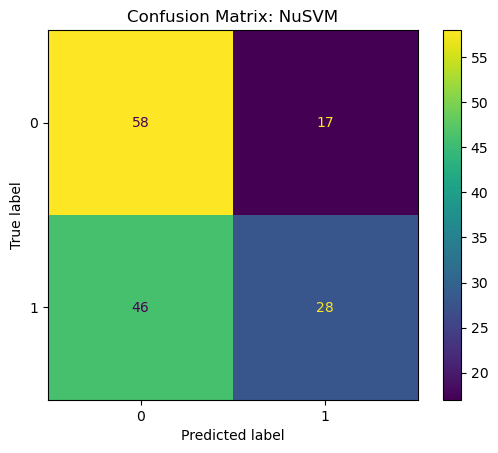

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.77      0.65        75
           1       0.62      0.38      0.47        74

    accuracy                           0.58       149
   macro avg       0.59      0.58      0.56       149
weighted avg       0.59      0.58      0.56       149


Evaluating KNN
Training Accuracy: 0.8521
Test Accuracy: 0.6980


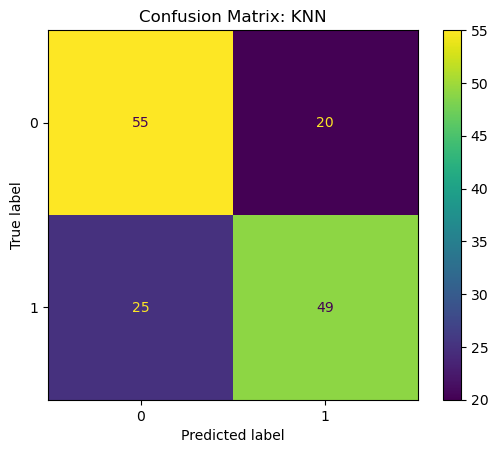

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.73      0.71        75
           1       0.71      0.66      0.69        74

    accuracy                           0.70       149
   macro avg       0.70      0.70      0.70       149
weighted avg       0.70      0.70      0.70       149


Evaluating GaussianNB
Training Accuracy: 0.5412
Test Accuracy: 0.5570


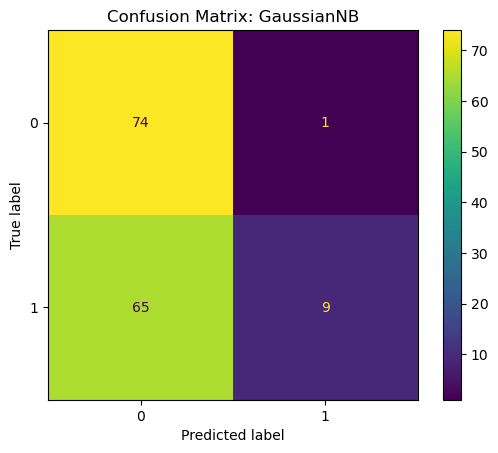

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.99      0.69        75
           1       0.90      0.12      0.21        74

    accuracy                           0.56       149
   macro avg       0.72      0.55      0.45       149
weighted avg       0.71      0.56      0.45       149


Evaluating MultinomialNB
Training Accuracy: 0.5630
Test Accuracy: 0.5705


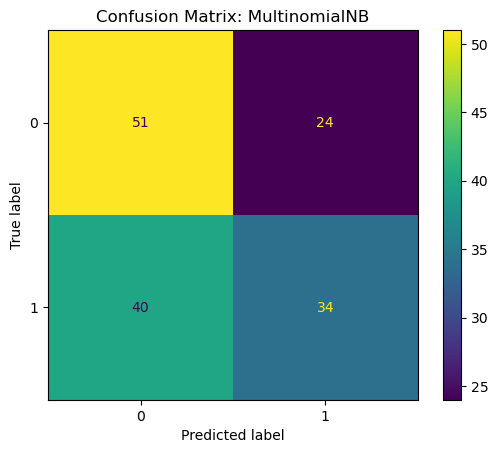

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.68      0.61        75
           1       0.59      0.46      0.52        74

    accuracy                           0.57       149
   macro avg       0.57      0.57      0.56       149
weighted avg       0.57      0.57      0.57       149


Evaluating BernoulliNB
Training Accuracy: 0.5798
Test Accuracy: 0.5503


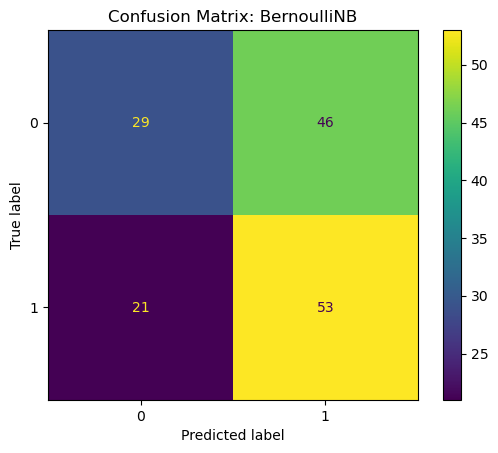

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.39      0.46        75
           1       0.54      0.72      0.61        74

    accuracy                           0.55       149
   macro avg       0.56      0.55      0.54       149
weighted avg       0.56      0.55      0.54       149


Evaluating ComplementNB
Training Accuracy: 0.5630
Test Accuracy: 0.5705


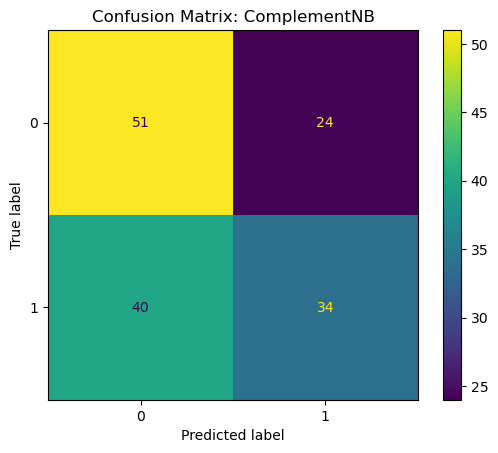

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.68      0.61        75
           1       0.59      0.46      0.52        74

    accuracy                           0.57       149
   macro avg       0.57      0.57      0.56       149
weighted avg       0.57      0.57      0.57       149


Evaluating DecisionTree
Training Accuracy: 0.9966
Test Accuracy: 0.8993


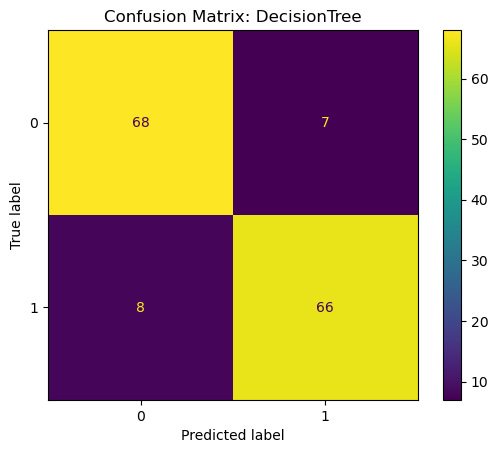

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        75
           1       0.90      0.89      0.90        74

    accuracy                           0.90       149
   macro avg       0.90      0.90      0.90       149
weighted avg       0.90      0.90      0.90       149


Evaluating ExtraTree
Training Accuracy: 0.9966
Test Accuracy: 0.9060


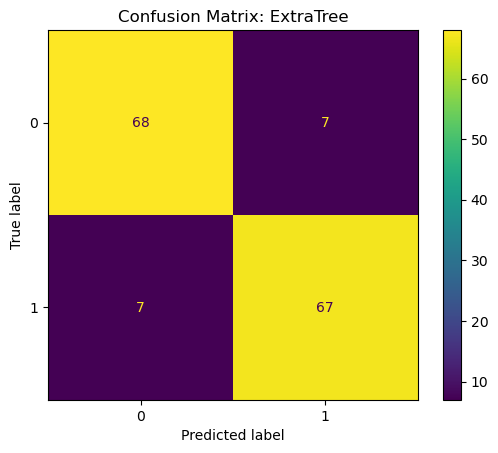

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        75
           1       0.91      0.91      0.91        74

    accuracy                           0.91       149
   macro avg       0.91      0.91      0.91       149
weighted avg       0.91      0.91      0.91       149


Evaluating MLPClassifier
Training Accuracy: 0.8303
Test Accuracy: 0.7785


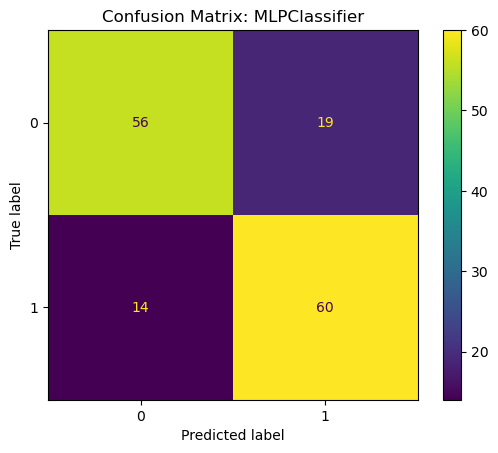

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.75      0.77        75
           1       0.76      0.81      0.78        74

    accuracy                           0.78       149
   macro avg       0.78      0.78      0.78       149
weighted avg       0.78      0.78      0.78       149


Evaluating LDA
Training Accuracy: 0.7328
Test Accuracy: 0.6980


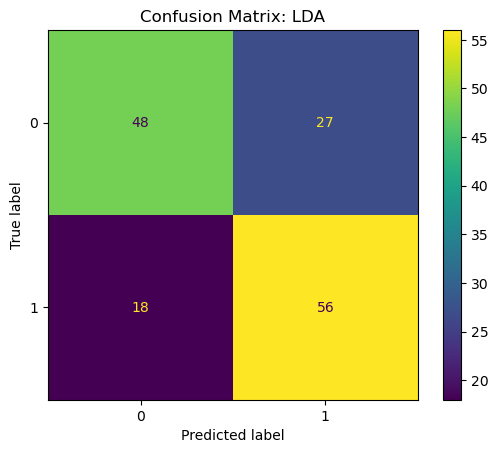

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.64      0.68        75
           1       0.67      0.76      0.71        74

    accuracy                           0.70       149
   macro avg       0.70      0.70      0.70       149
weighted avg       0.70      0.70      0.70       149


Evaluating QDA
Training Accuracy: 0.5445
Test Accuracy: 0.5235


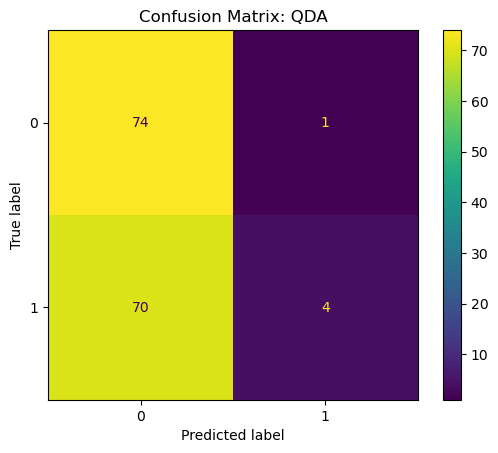

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.99      0.68        75
           1       0.80      0.05      0.10        74

    accuracy                           0.52       149
   macro avg       0.66      0.52      0.39       149
weighted avg       0.66      0.52      0.39       149


Evaluating GaussianProcess
Training Accuracy: 0.8151
Test Accuracy: 0.7517


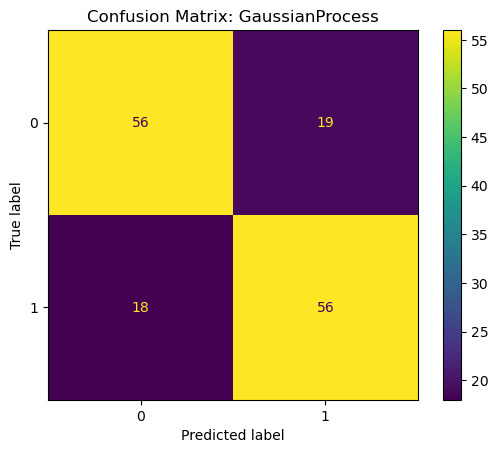

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.75      0.75        75
           1       0.75      0.76      0.75        74

    accuracy                           0.75       149
   macro avg       0.75      0.75      0.75       149
weighted avg       0.75      0.75      0.75       149


Evaluating LabelPropagation
Training Accuracy: 0.9899
Test Accuracy: 0.9396


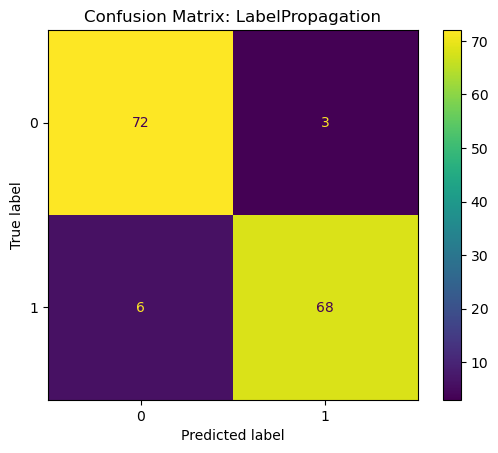

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        75
           1       0.96      0.92      0.94        74

    accuracy                           0.94       149
   macro avg       0.94      0.94      0.94       149
weighted avg       0.94      0.94      0.94       149


Evaluating LabelSpreading
Training Accuracy: 0.9866
Test Accuracy: 0.9329


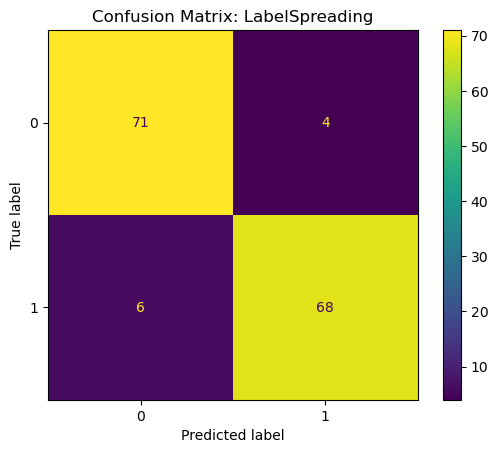

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93        75
           1       0.94      0.92      0.93        74

    accuracy                           0.93       149
   macro avg       0.93      0.93      0.93       149
weighted avg       0.93      0.93      0.93       149



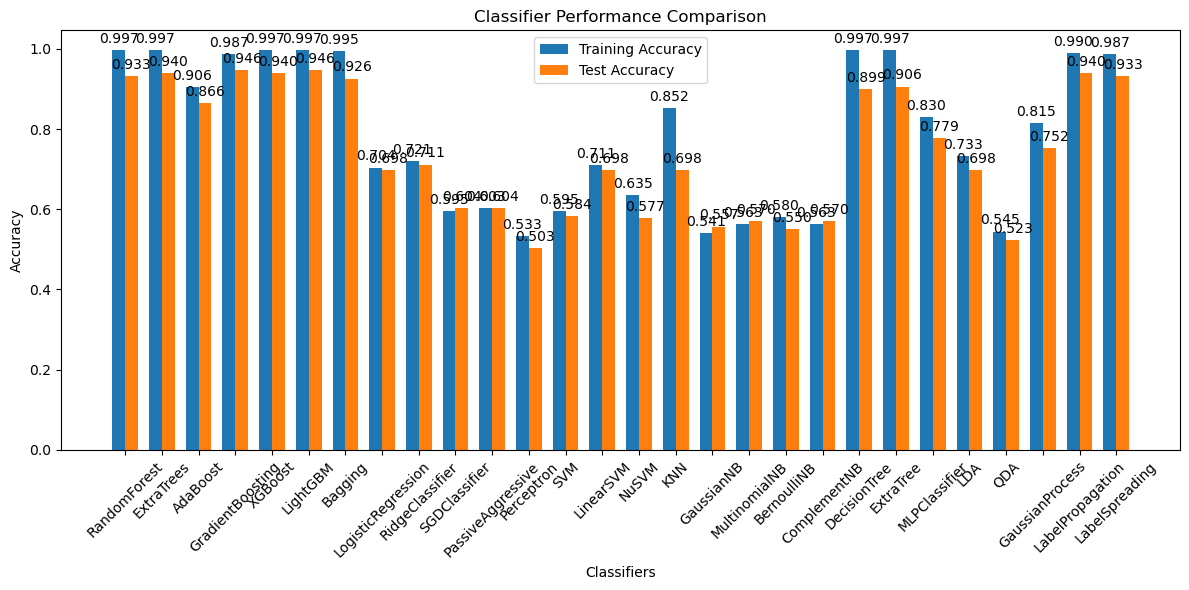

In [5]:
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, BaggingClassifier, VotingClassifier
)
from sklearn.linear_model import (
    LogisticRegression, RidgeClassifier, SGDClassifier, 
    PassiveAggressiveClassifier, Perceptron
)
from sklearn.svm import SVC, NuSVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from collections import Counter

# Find the most frequent label for outlier_label
most_frequent_label = Counter(y_train).most_common(1)[0][0]

classifiers = {
    # Ensemble Methods
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'Bagging': BaggingClassifier(n_estimators=10, random_state=42),
    
    # Linear Models
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RidgeClassifier': RidgeClassifier(random_state=42),
    'SGDClassifier': SGDClassifier(random_state=42, max_iter=1000),
    'PassiveAggressive': PassiveAggressiveClassifier(random_state=42, max_iter=1000),
    'Perceptron': Perceptron(random_state=42, max_iter=1000),
    
    # Support Vector Machines
    'SVM': SVC(random_state=42, probability=True),
    'LinearSVM': LinearSVC(random_state=42, max_iter=1000),
    'NuSVM': NuSVC(random_state=42, probability=True),
    
    # Nearest Neighbors
    'KNN': KNeighborsClassifier(n_neighbors=5),
    
    # Naive Bayes
    'GaussianNB': GaussianNB(),
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB(),
    'ComplementNB': ComplementNB(),
    
    # Tree-based
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'ExtraTree': ExtraTreeClassifier(random_state=42),
    
    # Neural Networks
    'MLPClassifier': MLPClassifier(random_state=42, max_iter=500),
    
    # Discriminant Analysis
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    
    # Gaussian Process
    'GaussianProcess': GaussianProcessClassifier(random_state=42),
    
    # Semi-supervised (requires both labeled and unlabeled data)
    'LabelPropagation': LabelPropagation(),
    'LabelSpreading': LabelSpreading(),
}

results = {}
for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Evaluating {name}")
    print(f"{'='*50}")
    clf.fit(X_train, y_train)
    train_acc = clf.score(X_train, y_train)
    test_acc = clf.score(X_test, y_test)
    y_pred = clf.predict(X_test)
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix: {name}")
    plt.show()
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
    results[name] = {'train_accuracy': train_acc, 'test_accuracy': test_acc}

# Plot comparison of all classifier results
import numpy as np
names = list(results.keys())
train_accuracies = [results[name]['train_accuracy'] for name in names]
test_accuracies = [results[name]['test_accuracy'] for name in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, train_accuracies, width, label='Training Accuracy')
rects2 = ax.bar(x + width/2, test_accuracies, width, label='Test Accuracy')

ax.set_xlabel('Classifiers')
ax.set_ylabel('Accuracy')
ax.set_title('Classifier Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45)
ax.legend()

# Add value labels on bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()
